## Objetivo del NB-01

El objetivo de este notebook es ejecutar y validar la primera fase práctica del MVP: la adquisición, limpieza, ajuste y enriquecimiento técnico de los datos OHLCV.

A partir de un universo de 40 activos del S&P 500, se descargan series históricas diarias para el período 2018-2025, se estandariza la estructura de datos, se construyen precios OHLC ajustados y se calculan los indicadores técnicos definidos en la metodología: Ichimoku, MACD, RSI, estocástico, ATR, volumen relativo y Heiken Ashi.

El resultado esperado es un dataset maestro consolidado que servirá como entrada para el NB-02, donde se generarán las señales técnicas candidatas.

In [7]:
from NB_01_data_pipeline_v2 import PipelineConfig, run_pipeline

cfg = PipelineConfig()

print("Importación correcta.")
print("Cantidad de tickers:", len(cfg.tickers))
print("Fecha inicio:", cfg.start_date)
print("Fecha fin:", cfg.end_date)

Importación correcta.
Cantidad de tickers: 40
Fecha inicio: 2018-01-01
Fecha fin: 2025-12-31


In [8]:
from pathlib import Path
import os

print("Carpeta actual:")
print(Path.cwd())

print("\nArchivos:")
for archivo in os.listdir():
    print(archivo)

Carpeta actual:
/Users/rbr/TFM_MVP

Archivos:
NB_01_data_pipeline_v2.py


In [9]:
from NB_01_data_pipeline_v2 import PipelineConfig, run_pipeline

cfg = PipelineConfig()

print("Importación correcta.")
print("Cantidad de tickers:", len(cfg.tickers))
print("Fecha inicio:", cfg.start_date)
print("Fecha fin:", cfg.end_date)
print("Ticker ejemplo:", cfg.example_plot_ticker)

Importación correcta.
Cantidad de tickers: 40
Fecha inicio: 2018-01-01
Fecha fin: 2025-12-31
Ticker ejemplo: AAPL


In [10]:
from NB_01_data_pipeline_v2 import PipelineConfig, run_pipeline

cfg_test = PipelineConfig(
    tickers=["AAPL"],
    save_master_parquet=False,   # evitamos depender de pyarrow por ahora
    save_master_csv=True,
    make_validation_plot=True
)

resultados_test = run_pipeline(cfg_test)

NB-01 v2 | Adquisición y enriquecimiento técnico de datos
Root del proyecto : /Users/rbr/TFM_MVP
Período          : 2018-01-01 -> 2025-12-31
Tickers          : 1
Benchmark        : SPY
[01/01] Procesando AAPL... OK | filas=2010 | cobertura=1.000

RESUMEN NB-01 v2
Tickers OK              : 1/1
Tickers con error       : 0
Rows master             : 2010
Criterio 'hecho' >= 30 tickers OK: NO CUMPLIDO
Processed master        : /Users/rbr/TFM_MVP/data/processed
Reports                 : /Users/rbr/TFM_MVP/data/reports
Figures                 : /Users/rbr/TFM_MVP/data/figures


In [11]:
from pathlib import Path

base = Path.cwd()

for carpeta in ["data/raw", "data/processed", "data/reports", "data/figures"]:
    ruta = base / carpeta
    print(f"\nContenido de {carpeta}:")
    if ruta.exists():
        for archivo in ruta.iterdir():
            print(" -", archivo.name)
    else:
        print(" Carpeta no existe")


Contenido de data/raw:
 - AAPL_ohlcv_raw.csv

Contenido de data/processed:
 - AAPL_ohlcv_indicadores.csv
 - market_ohlcv_indicators_master.csv

Contenido de data/reports:
 - quality_manifest_nb01.csv
 - summary_nb01.csv

Contenido de data/figures:
 - verificacion_indicadores_AAPL.png


In [12]:
import pandas as pd
from pathlib import Path

ruta_master = Path("data/processed/market_ohlcv_indicators_master.csv")

df_master = pd.read_csv(ruta_master)

print("Dimensiones del dataset:")
print(df_master.shape)

print("\nPrimeras filas:")
display(df_master.head())

print("\nÚltimas filas:")
display(df_master.tail())

print("\nColumnas:")
for col in df_master.columns:
    print(col)

Dimensiones del dataset:
(2010, 40)

Primeras filas:


,Date,Open,High,Low,Close,Adj_Close,Volume,Dividends,Stock_Splits,Ticker,Adj_Factor,Open_Adj,High_Adj,Low_Adj,Close_Adj,Has_Corporate_Action,Ichimoku_Tenkan,Ichimoku_Kijun,Ichimoku_Senkou_A,Ichimoku_Senkou_B,Kumo_Top,Kumo_Bottom,Price_Above_Kumo,MACD_Linea,MACD_Signal,MACD_Histograma,MACD_Bullish,RSI,Estocastico_K,Estocastico_D,ATR,ATR_Normalizado,Vol_Media_20,Volumen_Relativo,HA_Close,HA_Open,HA_High,HA_Low,HA_Alcista,Fecha
0,2018-01-02,42.540001,43.075001,42.314999,43.064999,40.267075,102223600.0,0.0,0.0,AAPL,0.93503,39.776186,40.276427,39.565802,40.267075,0,NaN,NaN,NaN,39.921114,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,39.971372,40.021630,40.276427,39.565802,0,2018-01-02
1,2018-01-03,43.132500,43.637501,42.990002,43.057499,40.260071,118071600.0,0.0,0.0,AAPL,0.93503,40.330199,40.802390,40.196959,40.260071,0,NaN,NaN,NaN,40.184096,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,40.397405,39.996501,40.802390,39.996501,1,2018-01-03
2,2018-01-04,43.134998,43.367500,43.020000,43.257500,40.447063,89738400.0,0.0,0.0,AAPL,0.93503,40.332521,40.549917,40.224995,40.447063,0,NaN,NaN,NaN,40.184096,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,40.388624,40.196953,40.549917,40.196953,1,2018-01-04
3,2018-01-05,43.360001,43.842499,43.262501,43.750000,40.907574,94640000.0,0.0,0.0,AAPL,0.93503,40.542912,40.994063,40.451747,40.907574,0,NaN,NaN,NaN,40.279932,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,40.724074,40.292789,40.994063,40.292789,1,2018-01-05
4,2018-01-08,43.587502,43.902500,43.482498,43.587502,40.755627,82271200.0,0.0,0.0,AAPL,0.93503,40.755627,41.050160,40.657445,40.755627,0,NaN,NaN,NaN,40.307981,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,40.804715,40.508431,41.050160,40.508431,1,2018-01-08



Últimas filas:


,Date,Open,High,Low,Close,Adj_Close,Volume,Dividends,Stock_Splits,Ticker,Adj_Factor,Open_Adj,High_Adj,Low_Adj,Close_Adj,Has_Corporate_Action,Ichimoku_Tenkan,Ichimoku_Kijun,Ichimoku_Senkou_A,Ichimoku_Senkou_B,Kumo_Top,Kumo_Bottom,Price_Above_Kumo,MACD_Linea,MACD_Signal,MACD_Histograma,MACD_Bullish,RSI,Estocastico_K,Estocastico_D,ATR,ATR_Normalizado,Vol_Media_20,Volumen_Relativo,HA_Close,HA_Open,HA_High,HA_Low,HA_Alcista,Fecha
2005,2025-12-23,270.839996,272.500000,269.559998,272.359985,271.854919,29642000.0,0.0,0.0,AAPL,0.998146,270.337749,271.994674,269.060124,271.854919,0,273.042715,276.456378,274.749547,265.698201,274.749547,265.698201,0,0.370033,1.727568,-1.357535,0,47.029014,30.427401,26.662996,4.730301,0.017400,45621460.0,0.649738,270.811867,271.942956,271.994674,269.060124,0,2025-12-23
2006,2025-12-24,272.339996,275.429993,272.200012,273.809998,273.302216,17910600.0,0.0,0.0,AAPL,0.998145,271.834940,274.919206,271.695216,273.302216,0,273.042715,276.456378,274.749547,266.047213,274.749547,266.047213,0,0.302190,1.442492,-1.140302,0,50.012074,48.343730,32.440691,4.622707,0.016914,44171280.0,0.405481,272.937895,271.377411,274.919206,271.377411,1,2025-12-24
2007,2025-12-26,274.160004,275.369995,272.859985,273.399994,272.892975,21521800.0,0.0,0.0,AAPL,0.998146,273.651575,274.859323,272.353968,272.892975,0,273.042715,276.546193,274.794454,266.047213,274.794454,266.047213,0,0.212947,1.196583,-0.983636,0,49.168893,48.863494,42.544875,4.471468,0.016385,43575800.0,0.493893,273.439460,272.157653,274.859323,272.157653,1,2025-12-26
2008,2025-12-29,272.690002,274.359985,272.350006,273.760010,273.252350,23715200.0,0.0,0.0,AAPL,0.998146,272.184327,273.851213,271.844961,273.252350,0,271.051421,276.631043,273.841232,266.261617,273.841232,266.261617,0,0.169269,0.991120,-0.821851,0,49.966629,51.591096,49.599440,4.295381,0.015719,43754780.0,0.542002,272.783213,272.798557,273.851213,271.844961,0,2025-12-29
2009,2025-12-30,272.809998,274.079987,272.279999,273.079987,272.573578,22139600.0,0.0,0.0,AAPL,0.998146,272.304090,273.571723,271.775074,272.573578,0,271.051421,276.631043,273.841232,266.261617,273.841232,266.261617,0,0.078972,0.808691,-0.729719,0,48.420936,46.439319,48.964636,4.116900,0.015104,42532375.0,0.520535,272.556116,272.790885,273.571723,271.775074,0,2025-12-30



Columnas:
Date
Open
High
Low
Close
Adj_Close
Volume
Dividends
Stock_Splits
Ticker
Adj_Factor
Open_Adj
High_Adj
Low_Adj
Close_Adj
Has_Corporate_Action
Ichimoku_Tenkan
Ichimoku_Kijun
Ichimoku_Senkou_A
Ichimoku_Senkou_B
Kumo_Top
Kumo_Bottom
Price_Above_Kumo
MACD_Linea
MACD_Signal
MACD_Histograma
MACD_Bullish
RSI
Estocastico_K
Estocastico_D
ATR
ATR_Normalizado
Vol_Media_20
Volumen_Relativo
HA_Close
HA_Open
HA_High
HA_Low
HA_Alcista
Fecha


In [13]:
import pandas as pd
from pathlib import Path

ruta_quality = Path("data/reports/quality_manifest_nb01.csv")
ruta_summary = Path("data/reports/summary_nb01.csv")

quality_df = pd.read_csv(ruta_quality)
summary_df = pd.read_csv(ruta_summary)

print("QUALITY MANIFEST:")
display(quality_df)

print("\nSUMMARY NB-01:")
display(summary_df)

QUALITY MANIFEST:


,Ticker,Status,Rows_Raw,Rows_Processed,Start_Date,End_Date,Duplicate_Dates_Removed,Rows_Dropped_Core_Missing,Coverage_Ratio,Missing_Pct_After_Clean,Indicators_NaN_Pct,Error_Message
0,AAPL,OK,2010,2010,2018-01-02,2025-12-30,0,0,1.0,0.0,0.799847,NaN



SUMMARY NB-01:


,processed_tickers,failed_tickers,insufficient_or_low_coverage,rows_master,min_processed_required,criterion_done
0,1,0,0,2010,30,False


In [14]:
import pandas as pd
from pathlib import Path

ruta_master = Path("data/processed/market_ohlcv_indicators_master.csv")
df_master = pd.read_csv(ruta_master)

# Quitamos las primeras 60 filas por ticker porque los indicadores necesitan historial previo
warmup_rows = 60

df_post_warmup = (
    df_master
    .sort_values(["Ticker", "Date"])
    .groupby("Ticker", group_keys=False)
    .apply(lambda x: x.iloc[warmup_rows:])
)

null_summary = (
    df_post_warmup
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

null_summary.columns = ["Columna", "Porcentaje_Nulos_Post_Warmup"]

display(null_summary)

print("Máximo porcentaje de nulos post-warmup:")
print(null_summary["Porcentaje_Nulos_Post_Warmup"].max())

,Columna,Porcentaje_Nulos_Post_Warmup
0,Date,0.0
1,Open,0.0
2,Price_Above_Kumo,0.0
3,MACD_Linea,0.0
4,MACD_Signal,0.0
5,MACD_Histograma,0.0
6,MACD_Bullish,0.0
7,RSI,0.0
8,Estocastico_K,0.0
9,Estocastico_D,0.0


Máximo porcentaje de nulos post-warmup:
0.0


In [15]:
from NB_01_data_pipeline_v2 import PipelineConfig, run_pipeline

cfg_full = PipelineConfig(
    save_master_parquet=False,   # lo dejamos en False para evitar dependencia de pyarrow
    save_master_csv=True,
    save_quality_report=True,
    make_validation_plot=True,
    example_plot_ticker="AAPL"
)

resultados_full = run_pipeline(cfg_full)

NB-01 v2 | Adquisición y enriquecimiento técnico de datos
Root del proyecto : /Users/rbr/TFM_MVP
Período          : 2018-01-01 -> 2025-12-31
Tickers          : 40
Benchmark        : SPY
[01/40] Procesando AAPL... OK | filas=2010 | cobertura=1.000
[02/40] Procesando MSFT... OK | filas=2010 | cobertura=1.000
[03/40] Procesando NVDA... OK | filas=2010 | cobertura=1.000
[04/40] Procesando META... OK | filas=2010 | cobertura=1.000
[05/40] Procesando AVGO... OK | filas=2010 | cobertura=1.000
[06/40] Procesando CSCO... OK | filas=2010 | cobertura=1.000
[07/40] Procesando ACN... OK | filas=2010 | cobertura=1.000
[08/40] Procesando CRM... OK | filas=2010 | cobertura=1.000
[09/40] Procesando ADBE... OK | filas=2010 | cobertura=1.000
[10/40] Procesando ORCL... OK | filas=2010 | cobertura=1.000
[11/40] Procesando TXN... OK | filas=2010 | cobertura=1.000
[12/40] Procesando AMAT... OK | filas=2010 | cobertura=1.000
[13/40] Procesando QCOM... OK | filas=2010 | cobertura=1.000
[14/40] Procesando JNJ..

In [16]:
import pandas as pd
from pathlib import Path

quality_df = pd.read_csv("data/reports/quality_manifest_nb01.csv")
summary_df = pd.read_csv("data/reports/summary_nb01.csv")

print("Resumen NB-01:")
display(summary_df)

print("\nDistribución de estados:")
display(quality_df["Status"].value_counts())

print("\nQuality manifest completo:")
display(quality_df)

print("\nTickers con algún problema:")
display(quality_df[quality_df["Status"] != "OK"])

Resumen NB-01:


,processed_tickers,failed_tickers,insufficient_or_low_coverage,rows_master,min_processed_required,criterion_done
0,40,0,0,80400,30,True



Distribución de estados:


Status
OK    40
Name: count, dtype: int64


Quality manifest completo:


,Ticker,Status,Rows_Raw,Rows_Processed,Start_Date,End_Date,Duplicate_Dates_Removed,Rows_Dropped_Core_Missing,Coverage_Ratio,Missing_Pct_After_Clean,Indicators_NaN_Pct,Error_Message
0,AAPL,OK,2010,2010,2018-01-02,2025-12-30,0,0,1.0,0.0,0.799847,NaN
1,ABT,OK,2010,2010,2018-01-02,2025-12-30,0,0,1.0,0.0,0.799847,NaN
2,ACN,OK,2010,2010,2018-01-02,2025-12-30,0,0,1.0,0.0,0.799847,NaN
3,ADBE,OK,2010,2010,2018-01-02,2025-12-30,0,0,1.0,0.0,0.799847,NaN
4,AMAT,OK,2010,2010,2018-01-02,2025-12-30,0,0,1.0,0.0,0.799847,NaN
5,AMZN,OK,2010,2010,2018-01-02,2025-12-30,0,0,1.0,0.0,0.799847,NaN
6,AVGO,OK,2010,2010,2018-01-02,2025-12-30,0,0,1.0,0.0,0.799847,NaN
7,BAC,OK,2010,2010,2018-01-02,2025-12-30,0,0,1.0,0.0,0.799847,NaN
8,BRK-B,OK,2010,2010,2018-01-02,2025-12-30,0,0,1.0,0.0,0.799847,NaN
9,CRM,OK,2010,2010,2018-01-02,2025-12-30,0,0,1.0,0.0,0.799847,NaN



Tickers con algún problema:


,Ticker,Status,Rows_Raw,Rows_Processed,Start_Date,End_Date,Duplicate_Dates_Removed,Rows_Dropped_Core_Missing,Coverage_Ratio,Missing_Pct_After_Clean,Indicators_NaN_Pct,Error_Message


## Validación visual del dataset generado

Una vez ejecutado el pipeline completo, se realizan validaciones gráficas para comprobar la cobertura del universo de activos, la consistencia del número de registros por ticker y la ausencia de problemas estructurales antes de avanzar hacia la generación de señales técnicas.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Rutas principales generadas por el NB-01
ruta_master = Path("data/processed/market_ohlcv_indicators_master.csv")
ruta_quality = Path("data/reports/quality_manifest_nb01.csv")
figures_dir = Path("data/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# Carga de datasets de control
df_master = pd.read_csv(ruta_master, parse_dates=["Date", "Fecha"])
quality_df = pd.read_csv(ruta_quality)

print("Dataset maestro cargado:")
print(df_master.shape)

print("\nTickers únicos:")
print(df_master["Ticker"].nunique())

print("\nEstados del quality manifest:")
display(quality_df["Status"].value_counts())

Dataset maestro cargado:
(80400, 40)

Tickers únicos:
40

Estados del quality manifest:


Status
OK    40
Name: count, dtype: int64

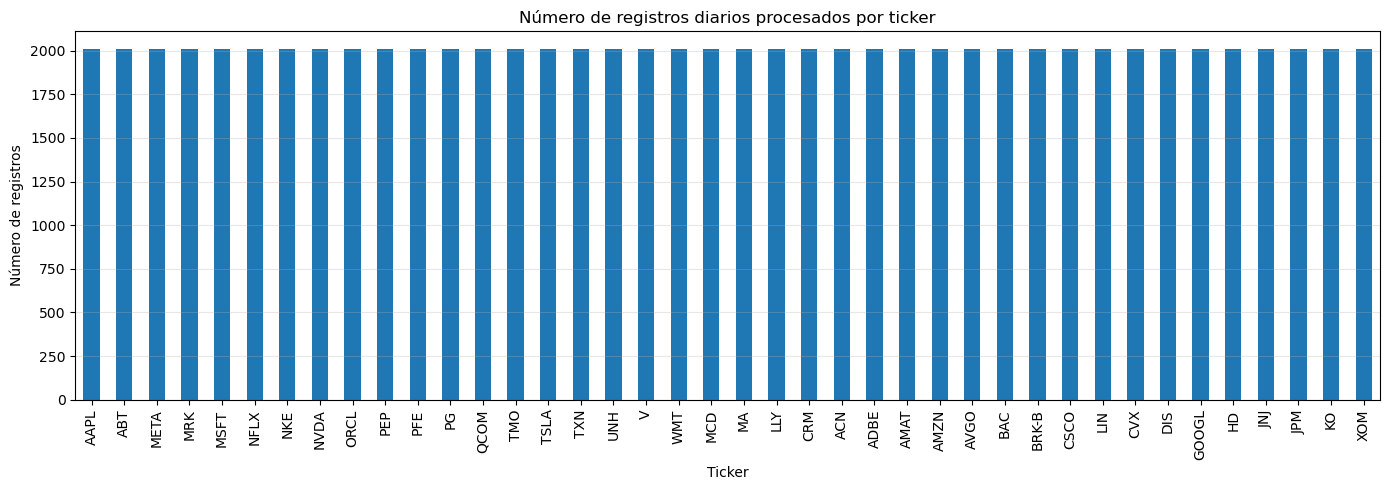

Gráfico guardado en: data/figures/nb01_registros_por_ticker.png


In [18]:
# ============================================================
# GRÁFICO 1: COBERTURA DE REGISTROS POR TICKER
# ============================================================

rows_by_ticker = (
    df_master
    .groupby("Ticker")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 5))
rows_by_ticker.plot(kind="bar")
plt.title("Número de registros diarios procesados por ticker")
plt.xlabel("Ticker")
plt.ylabel("Número de registros")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

output_path = figures_dir / "nb01_registros_por_ticker.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Gráfico guardado en: {output_path}")

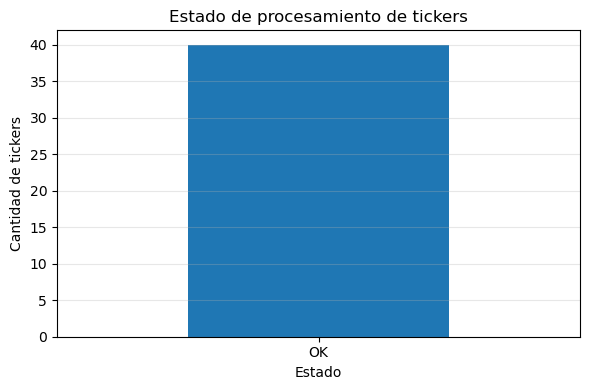

Gráfico guardado en: data/figures/nb01_estado_procesamiento_tickers.png


In [19]:
# ============================================================
# GRÁFICO 2: ESTADO DE PROCESAMIENTO POR TICKER
# ============================================================

status_counts = quality_df["Status"].value_counts()

plt.figure(figsize=(6, 4))
status_counts.plot(kind="bar")
plt.title("Estado de procesamiento de tickers")
plt.xlabel("Estado")
plt.ylabel("Cantidad de tickers")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

output_path = figures_dir / "nb01_estado_procesamiento_tickers.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Gráfico guardado en: {output_path}")

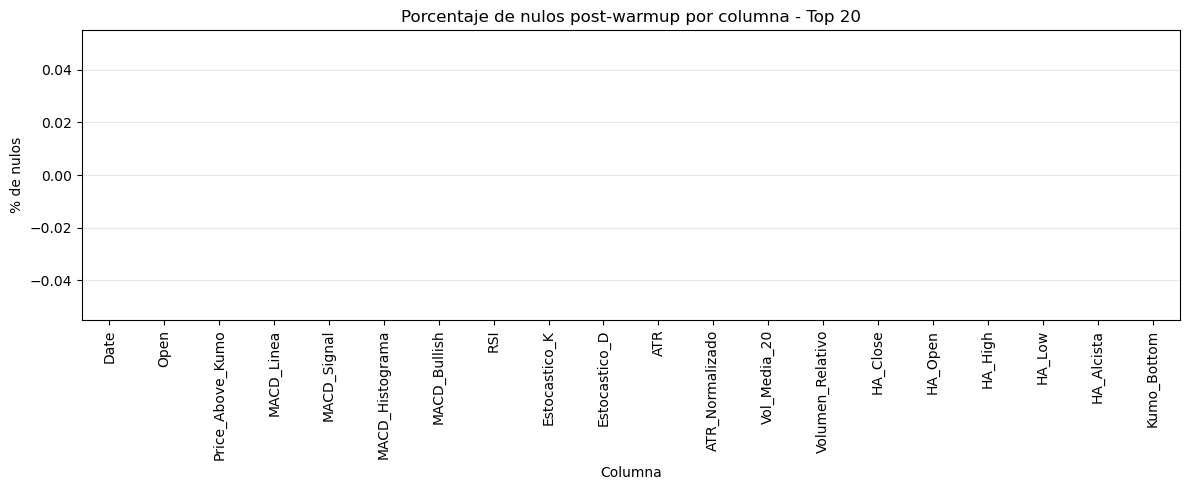

Máximo porcentaje de nulos post-warmup: 0.0000%
Gráfico guardado en: data/figures/nb01_nulos_post_warmup_top20.png


In [20]:
# ============================================================
# GRÁFICO 3: NULOS POST-WARMUP
# ============================================================

warmup_rows = 60

df_post_warmup = (
    df_master
    .sort_values(["Ticker", "Date"])
    .groupby("Ticker", group_keys=False)
    .apply(lambda x: x.iloc[warmup_rows:])
)

null_summary = (
    df_post_warmup
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
null_summary.head(20).plot(kind="bar")
plt.title("Porcentaje de nulos post-warmup por columna - Top 20")
plt.xlabel("Columna")
plt.ylabel("% de nulos")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

output_path = figures_dir / "nb01_nulos_post_warmup_top20.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Máximo porcentaje de nulos post-warmup: {null_summary.max():.4f}%")
print(f"Gráfico guardado en: {output_path}")

In [21]:
from NB_01_data_pipeline_v2 import create_validation_plot, safe_ticker_name

ticker_ejemplo = "NVDA"

create_validation_plot(
    master_df=df_master,
    ticker=ticker_ejemplo,
    figure_path=figures_dir / f"verificacion_indicadores_{safe_ticker_name(ticker_ejemplo)}.png"
)

print(f"Gráfico de validación generado para {ticker_ejemplo}")

Gráfico de validación generado para NVDA


## Validación visual 1: indicadores técnicos calculados

Este gráfico permite verificar que los indicadores técnicos fueron calculados correctamente para el ticker de muestra. Se muestran precio e Ichimoku, MACD, RSI, Estocástico, ATR y Volumen Relativo.

Existe el archivo: True


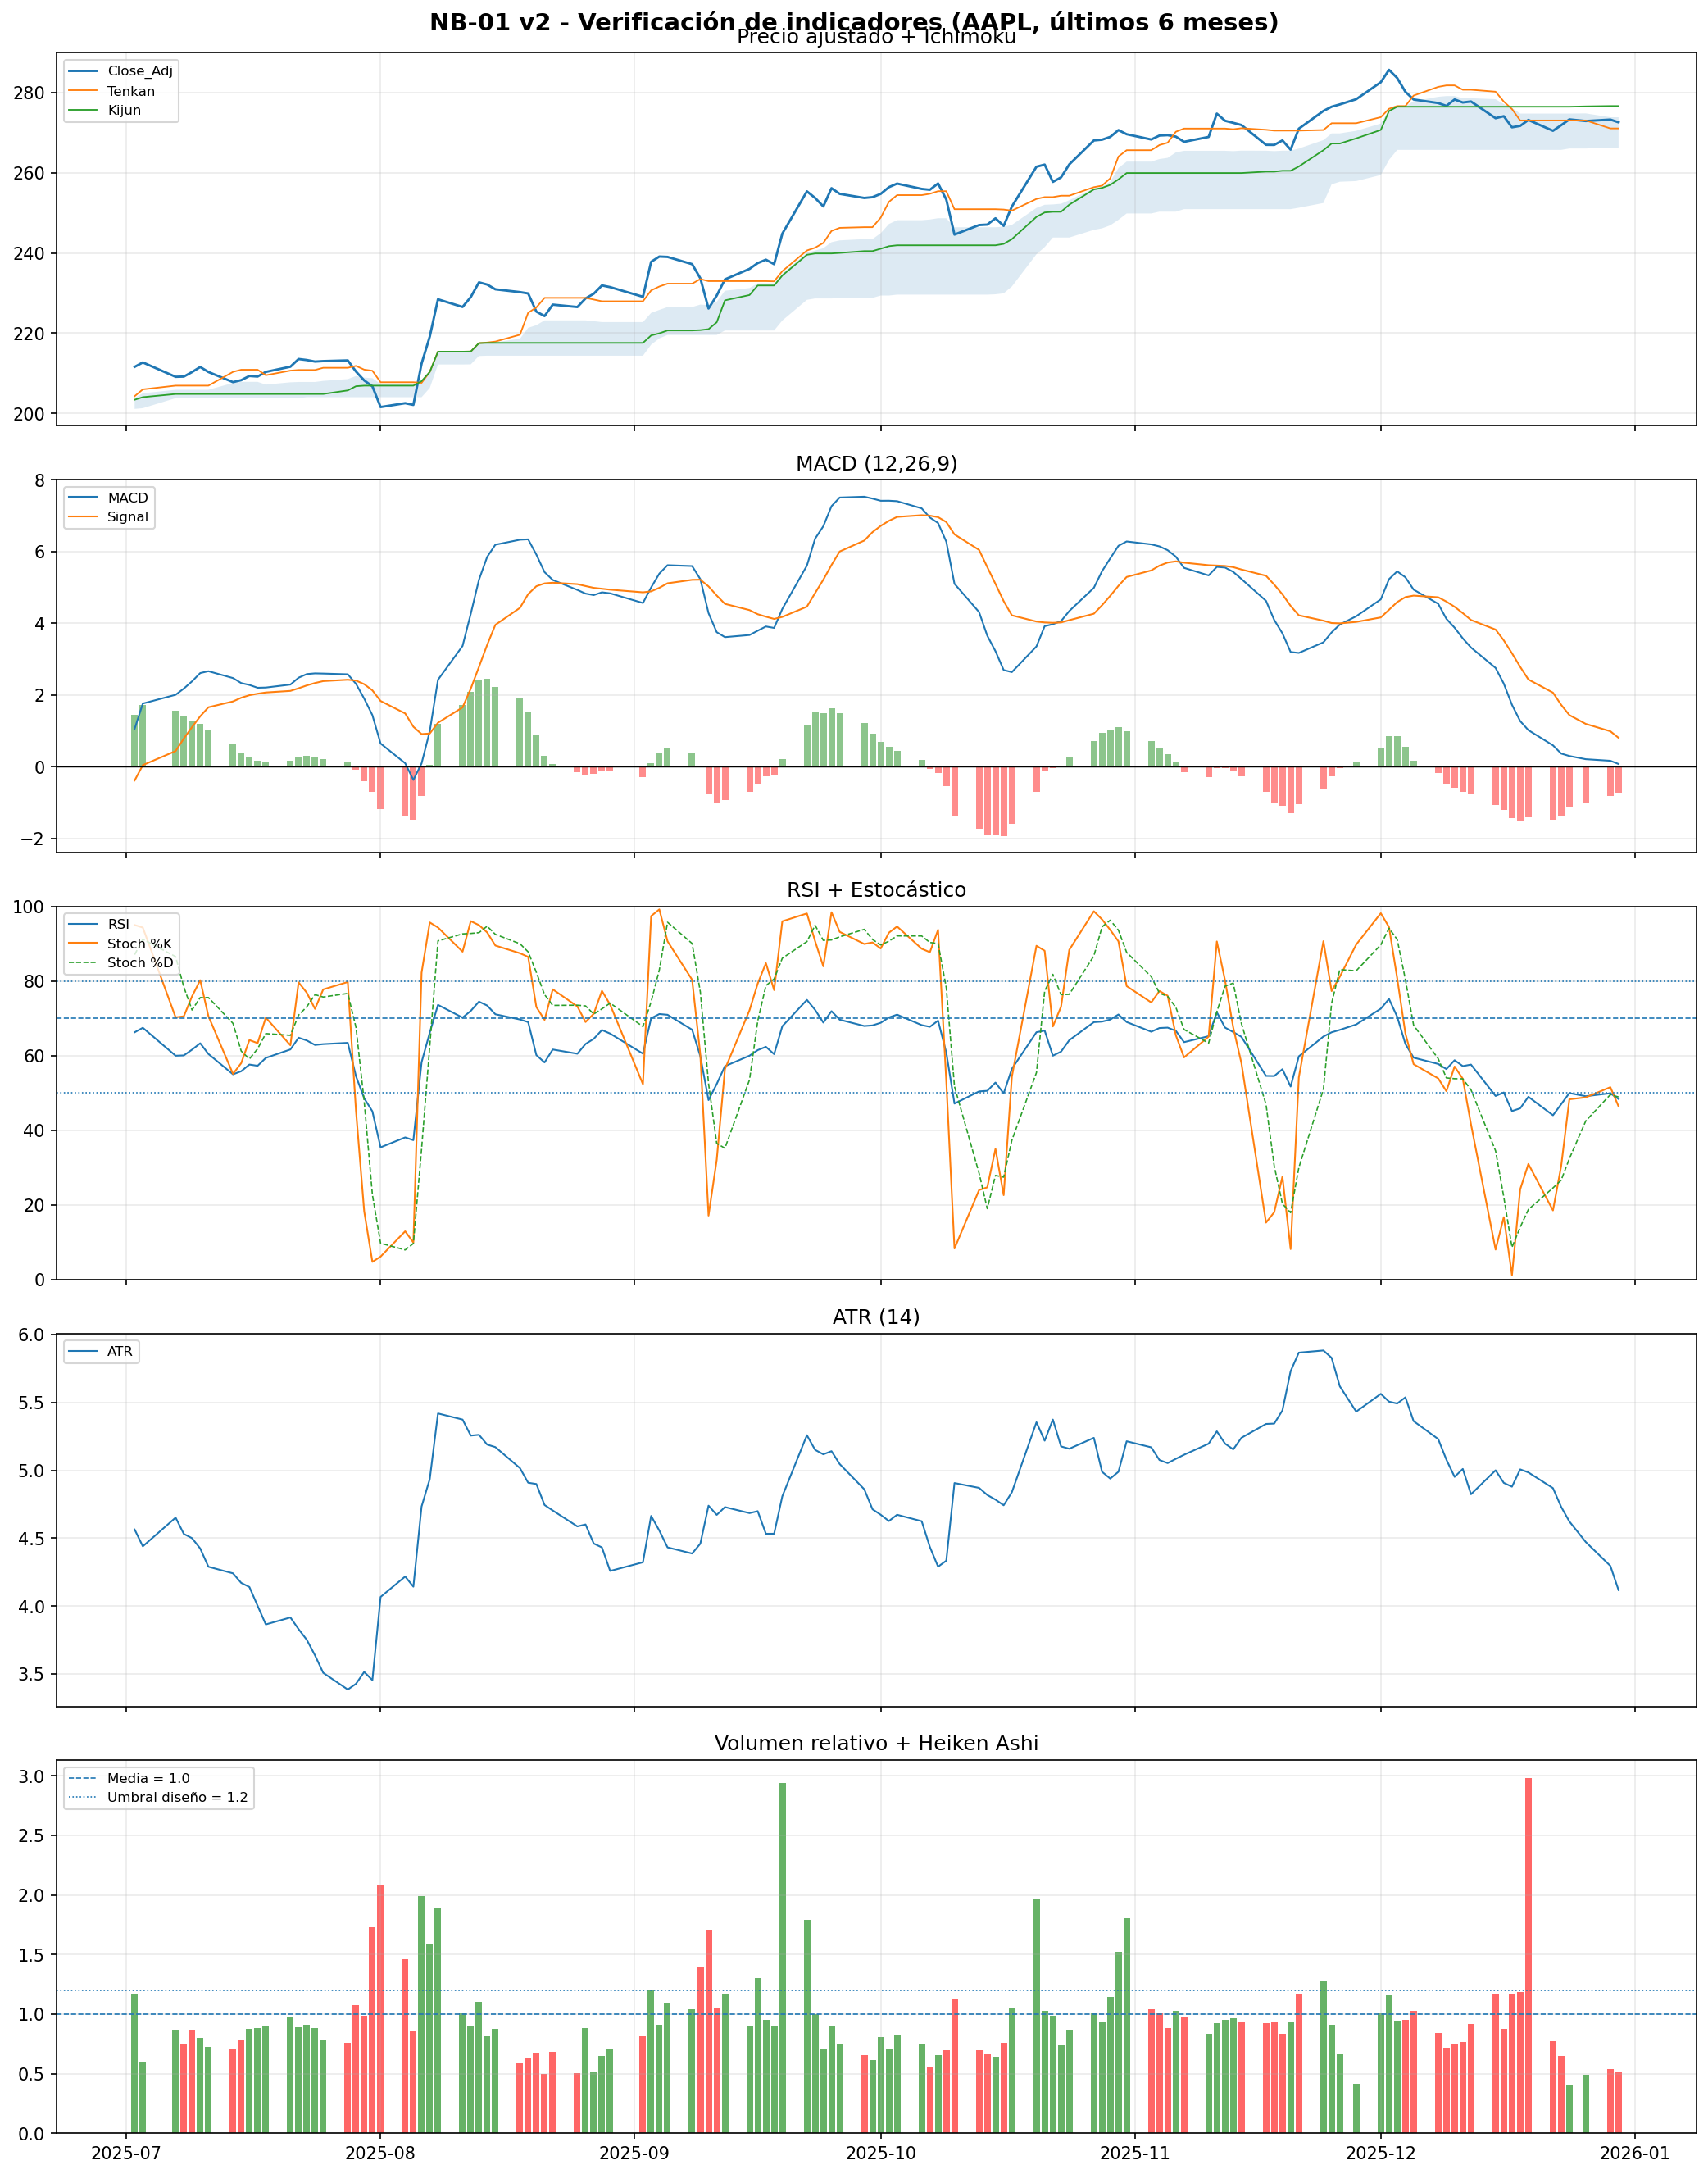

In [22]:
from IPython.display import Image, display
from pathlib import Path

ruta_fig = Path("data/figures/verificacion_indicadores_AAPL.png")

print("Existe el archivo:", ruta_fig.exists())
display(Image(filename=str(ruta_fig)))

## Validación visual 2: velas japonesas e Ichimoku

Este gráfico permite comprobar visualmente la integración entre las velas de precio ajustado y el indicador Ichimoku, reproduciendo una vista más cercana a la utilizada en plataformas de análisis técnico como TradingView.

In [23]:
import pandas as pd
from pathlib import Path

ruta_aapl = Path("data/processed/AAPL_ohlcv_indicadores.csv")
df_aapl = pd.read_csv(ruta_aapl, parse_dates=["Date", "Fecha"])

print(df_aapl.shape)
display(df_aapl.head())

(2010, 40)


,Date,Open,High,Low,Close,Adj_Close,Volume,Dividends,Stock_Splits,Ticker,Adj_Factor,Open_Adj,High_Adj,Low_Adj,Close_Adj,Has_Corporate_Action,Ichimoku_Tenkan,Ichimoku_Kijun,Ichimoku_Senkou_A,Ichimoku_Senkou_B,Kumo_Top,Kumo_Bottom,Price_Above_Kumo,MACD_Linea,MACD_Signal,MACD_Histograma,MACD_Bullish,RSI,Estocastico_K,Estocastico_D,ATR,ATR_Normalizado,Vol_Media_20,Volumen_Relativo,HA_Close,HA_Open,HA_High,HA_Low,HA_Alcista,Fecha
0,2018-01-02,42.540001,43.075001,42.314999,43.064999,40.267075,102223600.0,0.0,0.0,AAPL,0.93503,39.776186,40.276427,39.565802,40.267075,0,NaN,NaN,NaN,39.921114,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,39.971372,40.021630,40.276427,39.565802,0,2018-01-02
1,2018-01-03,43.132500,43.637501,42.990002,43.057499,40.260071,118071600.0,0.0,0.0,AAPL,0.93503,40.330199,40.802390,40.196959,40.260071,0,NaN,NaN,NaN,40.184096,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,40.397405,39.996501,40.802390,39.996501,1,2018-01-03
2,2018-01-04,43.134998,43.367500,43.020000,43.257500,40.447063,89738400.0,0.0,0.0,AAPL,0.93503,40.332521,40.549917,40.224995,40.447063,0,NaN,NaN,NaN,40.184096,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,40.388624,40.196953,40.549917,40.196953,1,2018-01-04
3,2018-01-05,43.360001,43.842499,43.262501,43.750000,40.907574,94640000.0,0.0,0.0,AAPL,0.93503,40.542912,40.994063,40.451747,40.907574,0,NaN,NaN,NaN,40.279932,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,40.724074,40.292789,40.994063,40.292789,1,2018-01-05
4,2018-01-08,43.587502,43.902500,43.482498,43.587502,40.755627,82271200.0,0.0,0.0,AAPL,0.93503,40.755627,41.050160,40.657445,40.755627,0,NaN,NaN,NaN,40.307981,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,40.804715,40.508431,41.050160,40.508431,1,2018-01-08


In [24]:
try:
    import mplfinance as mpf
    print("mplfinance está instalado correctamente.")
except ImportError:
    print("mplfinance NO está instalado.")

mplfinance NO está instalado.


In [26]:
%pip install mplfinance


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /Users/rbr/anaconda3/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
import mplfinance as mpf

print("mplfinance instalado correctamente")

mplfinance instalado correctamente


Gráfico guardado en: data/figures/nb01_aapl_velas_ichimoku_corregido.png


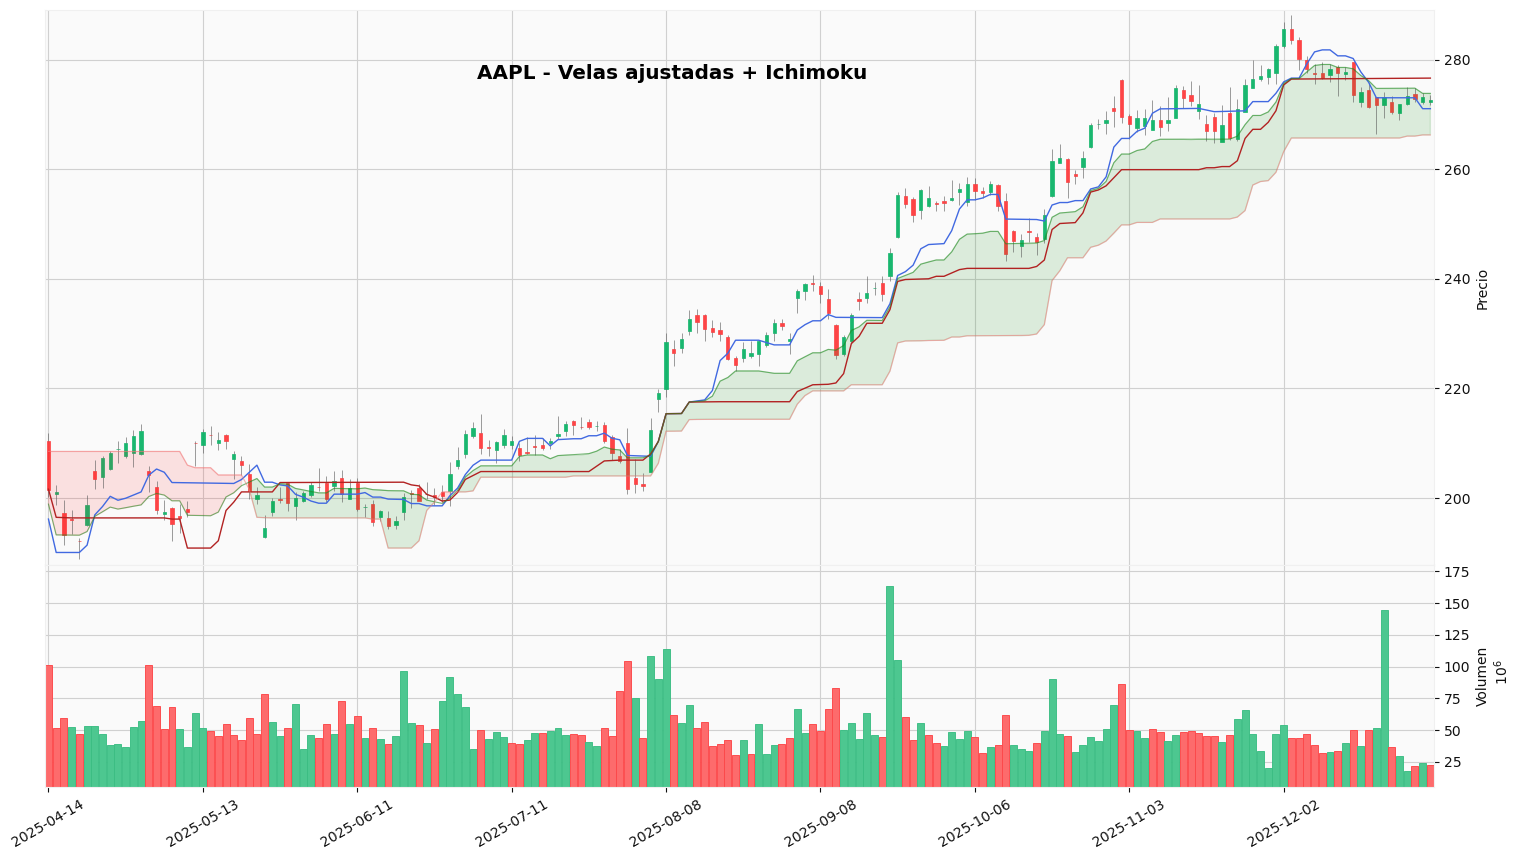

In [29]:
import pandas as pd
import mplfinance as mpf
from pathlib import Path

# ============================================================
# CARGA DEL DATASET DE AAPL
# ============================================================

ruta_aapl = Path("data/processed/AAPL_ohlcv_indicadores.csv")
df_aapl = pd.read_csv(ruta_aapl, parse_dates=["Date", "Fecha"])

df_plot = df_aapl.copy()
df_plot["Date"] = pd.to_datetime(df_plot["Date"])
df_plot = df_plot.set_index("Date").sort_index()

# Muestra reciente
df_plot = df_plot.tail(180)

# ============================================================
# DATOS OHLCV AJUSTADOS PARA VELAS
# ============================================================

df_candles = df_plot[["Open_Adj", "High_Adj", "Low_Adj", "Close_Adj", "Volume"]].copy()
df_candles.columns = ["Open", "High", "Low", "Close", "Volume"]

# ============================================================
# SERIES ICHIMOKU
# ============================================================

tenkan = df_plot["Ichimoku_Tenkan"]
kijun = df_plot["Ichimoku_Kijun"]
senkou_a = df_plot["Ichimoku_Senkou_A"]
senkou_b = df_plot["Ichimoku_Senkou_B"]

# Líneas superpuestas correctamente usando make_addplot
add_plots = [
    mpf.make_addplot(tenkan, color="royalblue", width=1.0),
    mpf.make_addplot(kijun, color="firebrick", width=1.0),
    mpf.make_addplot(senkou_a, color="forestgreen", width=0.8, alpha=0.6),
    mpf.make_addplot(senkou_b, color="lightcoral", width=0.8, alpha=0.6),
]

# Nube Ichimoku
cloud_fill = [
    dict(
        y1=senkou_a.values,
        y2=senkou_b.values,
        where=(senkou_a >= senkou_b).values,
        color="green",
        alpha=0.12
    ),
    dict(
        y1=senkou_a.values,
        y2=senkou_b.values,
        where=(senkou_a < senkou_b).values,
        color="red",
        alpha=0.10
    )
]

# ============================================================
# GRÁFICO DE VELAS + ICHIMOKU
# ============================================================

fig, axes = mpf.plot(
    df_candles,
    type="candle",
    style="yahoo",
    volume=True,
    addplot=add_plots,
    fill_between=cloud_fill,
    figsize=(16, 9),
    title="AAPL - Velas ajustadas + Ichimoku",
    ylabel="Precio",
    ylabel_lower="Volumen",
    xrotation=30,
    datetime_format="%Y-%m-%d",
    returnfig=True,
    tight_layout=True
)

# Guardar figura
figures_dir = Path("data/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

output_path = figures_dir / "nb01_aapl_velas_ichimoku_corregido.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")

print(f"Gráfico guardado en: {output_path}")

Gráfico guardado en: data/figures/nb01_aapl_velas_ichimoku_estocastico_atr.png


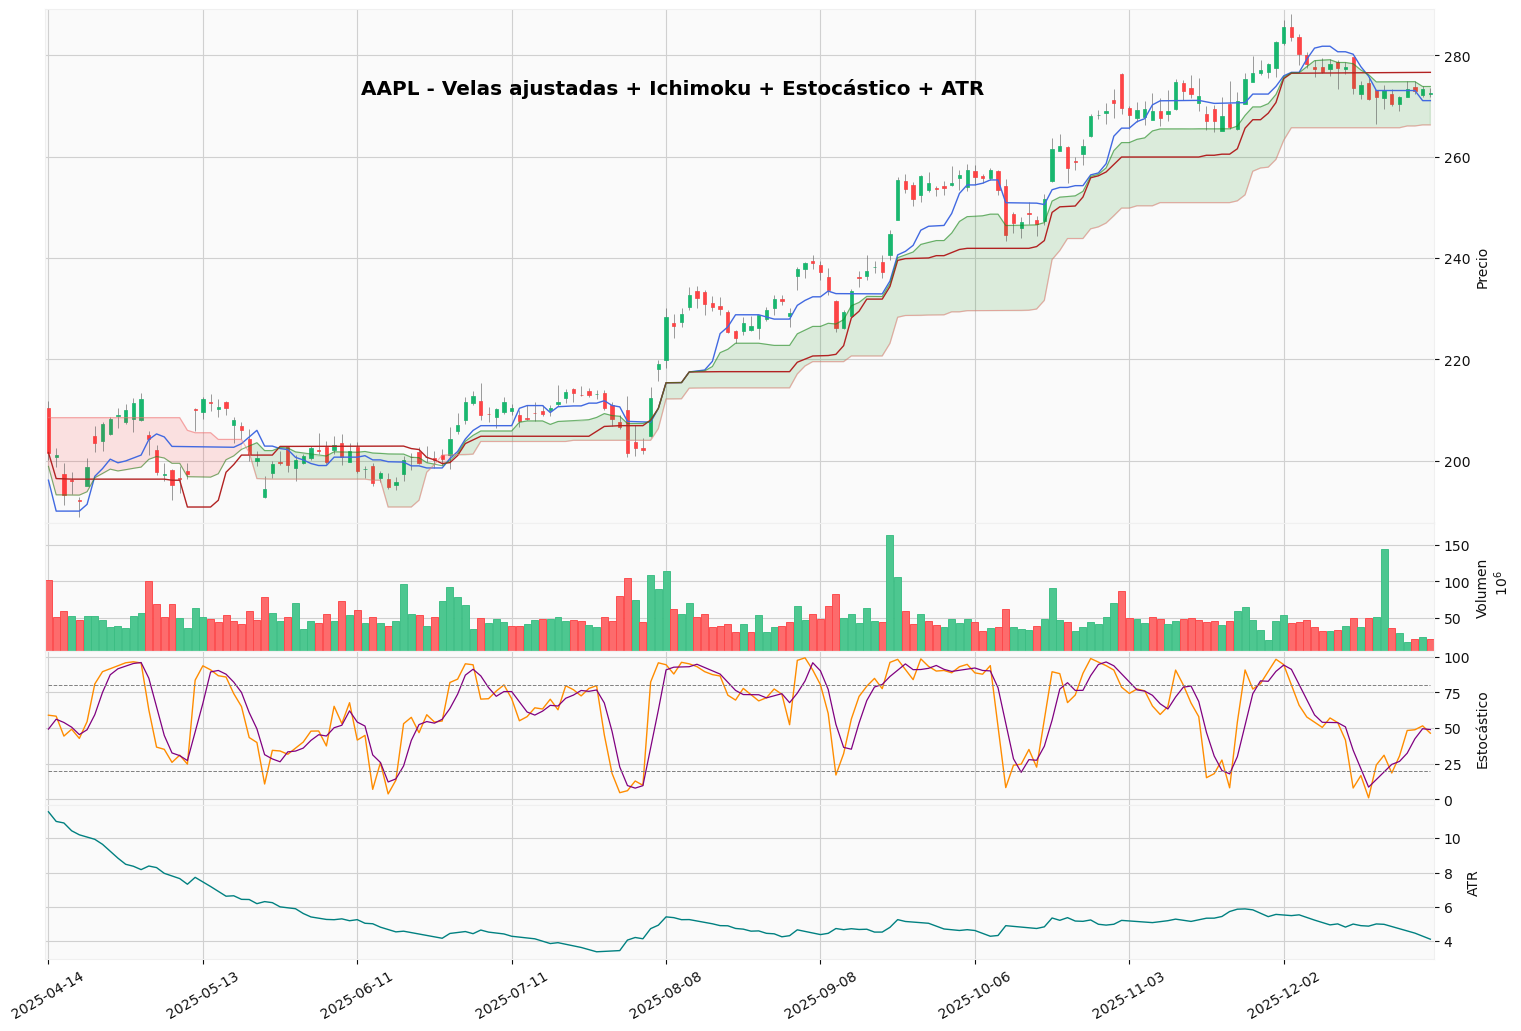

In [30]:
import pandas as pd
import mplfinance as mpf
from pathlib import Path

# ============================================================
# CARGA DEL DATASET DE AAPL
# ============================================================

ruta_aapl = Path("data/processed/AAPL_ohlcv_indicadores.csv")
df_aapl = pd.read_csv(ruta_aapl, parse_dates=["Date", "Fecha"])

df_plot = df_aapl.copy()
df_plot["Date"] = pd.to_datetime(df_plot["Date"])
df_plot = df_plot.set_index("Date").sort_index()

# Muestra reciente para visualización
df_plot = df_plot.tail(180)

# ============================================================
# DATOS OHLCV AJUSTADOS PARA VELAS
# ============================================================

df_candles = df_plot[["Open_Adj", "High_Adj", "Low_Adj", "Close_Adj", "Volume"]].copy()
df_candles.columns = ["Open", "High", "Low", "Close", "Volume"]

# ============================================================
# SERIES TÉCNICAS
# ============================================================

tenkan = df_plot["Ichimoku_Tenkan"]
kijun = df_plot["Ichimoku_Kijun"]
senkou_a = df_plot["Ichimoku_Senkou_A"]
senkou_b = df_plot["Ichimoku_Senkou_B"]

stoch_k = df_plot["Estocastico_K"]
stoch_d = df_plot["Estocastico_D"]
atr = df_plot["ATR"]

# Líneas horizontales del estocástico
stoch_80 = pd.Series(80, index=df_plot.index)
stoch_20 = pd.Series(20, index=df_plot.index)

# ============================================================
# ADDPLOTS
# ============================================================

add_plots = [
    # Panel principal: Ichimoku
    mpf.make_addplot(tenkan, color="royalblue", width=1.0, panel=0),
    mpf.make_addplot(kijun, color="firebrick", width=1.0, panel=0),
    mpf.make_addplot(senkou_a, color="forestgreen", width=0.8, alpha=0.6, panel=0),
    mpf.make_addplot(senkou_b, color="lightcoral", width=0.8, alpha=0.6, panel=0),

    # Panel 2: Estocástico
    mpf.make_addplot(stoch_k, color="darkorange", width=1.0, panel=2, ylabel="Estocástico"),
    mpf.make_addplot(stoch_d, color="purple", width=0.9, panel=2),
    mpf.make_addplot(stoch_80, color="gray", width=0.7, linestyle="--", panel=2),
    mpf.make_addplot(stoch_20, color="gray", width=0.7, linestyle="--", panel=2),

    # Panel 3: ATR
    mpf.make_addplot(atr, color="teal", width=1.0, panel=3, ylabel="ATR"),
]

# Nube Ichimoku
cloud_fill = [
    dict(
        y1=senkou_a.values,
        y2=senkou_b.values,
        where=(senkou_a >= senkou_b).values,
        color="green",
        alpha=0.12
    ),
    dict(
        y1=senkou_a.values,
        y2=senkou_b.values,
        where=(senkou_a < senkou_b).values,
        color="red",
        alpha=0.10
    )
]

# ============================================================
# GRÁFICO COMPLETO
# ============================================================

fig, axes = mpf.plot(
    df_candles,
    type="candle",
    style="yahoo",
    volume=True,
    addplot=add_plots,
    fill_between=cloud_fill,
    figsize=(16, 11),
    title="AAPL - Velas ajustadas + Ichimoku + Estocástico + ATR",
    ylabel="Precio",
    ylabel_lower="Volumen",
    panel_ratios=(4, 1, 1.2, 1.2),
    xrotation=30,
    datetime_format="%Y-%m-%d",
    returnfig=True,
    tight_layout=True
)

# ============================================================
# GUARDAR FIGURA
# ============================================================

figures_dir = Path("data/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

output_path = figures_dir / "nb01_aapl_velas_ichimoku_estocastico_atr.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")

print(f"Gráfico guardado en: {output_path}")

## Validación visual de los indicadores técnicos

Una vez ejecutado el pipeline completo de adquisición, limpieza y enriquecimiento técnico de datos, se realiza una validación visual sobre un ticker de muestra. En este caso se utiliza AAPL, con el objetivo de verificar que las series de precio ajustado y los indicadores técnicos calculados presentan un comportamiento coherente.

La figura incluye velas ajustadas, volumen, Ichimoku, oscilador estocástico y ATR. Esta validación no busca extraer todavía señales operativas, sino comprobar que los datos generados por el NB-01 son aptos para ser utilizados en el siguiente módulo del MVP.

In [31]:
import pandas as pd
from pathlib import Path

# ============================================================
# RESUMEN FINAL DEL NB-01
# ============================================================

ruta_master = Path("data/processed/market_ohlcv_indicators_master.csv")
ruta_quality = Path("data/reports/quality_manifest_nb01.csv")
ruta_summary = Path("data/reports/summary_nb01.csv")

df_master = pd.read_csv(ruta_master)
quality_df = pd.read_csv(ruta_quality)
summary_df = pd.read_csv(ruta_summary)

resumen_nb01 = {
    "Tickers procesados correctamente": int((quality_df["Status"] == "OK").sum()),
    "Tickers con error": int((quality_df["Status"] == "ERROR").sum()),
    "Total de tickers analizados": int(quality_df["Ticker"].nunique()),
    "Filas del dataset maestro": int(len(df_master)),
    "Fecha mínima": df_master["Date"].min(),
    "Fecha máxima": df_master["Date"].max(),
    "Columnas generadas": int(df_master.shape[1]),
    "Criterio de hecho cumplido": bool(summary_df["criterion_done"].iloc[0])
}

resumen_nb01_df = pd.DataFrame(
    resumen_nb01.items(),
    columns=["Métrica", "Valor"]
)

display(resumen_nb01_df)

,Métrica,Valor
0,Tickers procesados correctamente,40
1,Tickers con error,0
2,Total de tickers analizados,40
3,Filas del dataset maestro,80400
4,Fecha mínima,2018-01-02
5,Fecha máxima,2025-12-30
6,Columnas generadas,40
7,Criterio de hecho cumplido,True


## Conclusión del NB-01

El NB-01 fue ejecutado correctamente para los 40 tickers definidos en el universo experimental. El pipeline generó un dataset maestro con 80.400 observaciones diarias, sin tickers con error y con criterio de completitud cumplido.

Durante esta fase se descargaron datos OHLCV diarios, se estandarizó su estructura, se construyeron precios ajustados y se calcularon los indicadores técnicos definidos en la metodología del TFM: Ichimoku, MACD, RSI, estocástico, ATR, volumen relativo y Heiken Ashi.

Las validaciones realizadas confirman que el dataset resultante es consistente y puede utilizarse como entrada para el NB-02, donde se aplicará el filtro técnico determinista para generar señales candidatas.